# **NEURAL CTR**

Neural Click-Through-Rate. In this task, given a data set of 39 features containing info about an ad's impression and response amomng users, we know have to predict binary labels indicating 1 (user clicked) or 0 (user skipped).

In [28]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import roc_auc_score, accuracy_score, log_loss, average_precision_score, f1_score, brier_score_loss, precision_recall_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve

# Data Pre-processing

In [29]:
def preprocess_ctr_data(csv_path):
    print("Loading data...")
    
    col_names = ['label'] + [f'I{i}' for i in range(1, 14)] + [f'C{i}' for i in range(1, 27)]

    df = pd.read_csv(csv_path, names=col_names, header=None)

    df['label'] = pd.to_numeric(df['label'], errors='coerce')
    df = df.dropna(subset=['label'])
    
    numeric_cols = [f'I{i}' for i in range(1, 14)]
    categorical_cols = [f'C{i}' for i in range(1, 27)]

    train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
    
    print("Processing Numeric Features")
    for col in numeric_cols:
        train_df[col] = pd.to_numeric(train_df[col], errors='coerce')
        val_df[col] = pd.to_numeric(val_df[col], errors='coerce')
        
        median_val = train_df[col].median()
        train_df[col] = train_df[col].fillna(median_val)
        val_df[col] = val_df[col].fillna(median_val)

        min_val = train_df[col].min()
        train_df[col] = np.log1p(train_df[col] - min_val if min_val < 0 else train_df[col])
        val_df[col] = np.log1p(val_df[col] - min_val if min_val < 0 else val_df[col])

    scaler = StandardScaler()
    train_df[numeric_cols] = scaler.fit_transform(train_df[numeric_cols])
    val_df[numeric_cols] = scaler.transform(val_df[numeric_cols]) 

    print("Processing Categorical Features")

    train_df[categorical_cols] = train_df[categorical_cols].fillna('<UNK>')
    val_df[categorical_cols] = val_df[categorical_cols].fillna('<UNK>')
    
    train_df[categorical_cols] = train_df[categorical_cols].astype(str)
    val_df[categorical_cols] = val_df[categorical_cols].astype(str)

    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    train_df[categorical_cols] = encoder.fit_transform(train_df[categorical_cols])
    val_df[categorical_cols] = encoder.transform(val_df[categorical_cols])

    train_df[categorical_cols] = train_df[categorical_cols] + 1
    val_df[categorical_cols] = val_df[categorical_cols] + 1

    cat_dims = [int(train_df[col].max() + 2) for col in categorical_cols]
    
    return train_df, val_df, numeric_cols, categorical_cols, cat_dims

# Vanilla Neural Network

In [30]:
class CTRDataset(Dataset):
    def __init__(self, df, numeric_cols, categorical_cols):
        self.numeric = torch.tensor(df[numeric_cols].values, dtype=torch.float32)
        self.categorical = torch.tensor(df[categorical_cols].values, dtype=torch.long)
        self.labels = torch.tensor(df['label'].values, dtype=torch.float32)
        
    def __len__(self):
        return len(self.labels)
        
    def __getitem__(self, idx):
        return self.numeric[idx], self.categorical[idx], self.labels[idx]

class VanillaCTR(nn.Module):
    def __init__(self, num_numeric, cat_dims, embed_dim=16, hidden_dims=[128, 64]):
        super().__init__()
        
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_embeddings=dim, embedding_dim=embed_dim)
            for dim in cat_dims
        ])
        
        total_input_dim = num_numeric + (len(cat_dims) * embed_dim)

        layers = []
        in_dim = total_input_dim
        for out_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, out_dim))
            layers.append(nn.BatchNorm1d(out_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.2))
            in_dim = out_dim

        layers.append(nn.Linear(in_dim, 1))
        self.mlp = nn.Sequential(*layers)
        
    def forward(self, numeric_x, cat_x):
        cat_embeds = [emb(cat_x[:, i]) for i, emb in enumerate(self.embeddings)]

        cat_concat = torch.cat(cat_embeds, dim=1)

        x = torch.cat([numeric_x, cat_concat], dim=1) 
        
        logits = self.mlp(x).squeeze(1)

        return logits

# Execution and Evaluation

In [31]:
def train_and_evaluate(model, train_loader, val_loader, epochs=5, lr=0.001):
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    model = model.to(device)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    
    history = {
        'train_loss': [], 'val_loss': [], 'val_roc_auc': [], 
        'val_pr_auc': [], 'val_accuracy': [], 'val_f1': []
    }
    
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        for num_x, cat_x, labels in train_loader:
            num_x, cat_x, labels = num_x.to(device), cat_x.to(device), labels.to(device)
            
            optimizer.zero_grad()
            logits = model(num_x, cat_x)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            
            total_train_loss += loss.item() * len(labels)
            
        avg_train_loss = total_train_loss / len(train_loader.dataset)
        
        model.eval()
        total_val_loss = 0
        all_preds = []
        all_targets = []
        
        with torch.no_grad():
            for num_x, cat_x, labels in val_loader:
                num_x, cat_x, labels = num_x.to(device), cat_x.to(device), labels.to(device)
                logits = model(num_x, cat_x)
                loss = criterion(logits, labels)
                total_val_loss += loss.item() * len(labels)

                probs = torch.sigmoid(logits)
                all_preds.extend(probs.cpu().numpy())
                all_targets.extend(labels.cpu().numpy())
                
        avg_val_loss = total_val_loss / len(val_loader.dataset)
        all_preds = np.array(all_preds)
        all_targets = np.array(all_targets)
        
        roc_auc = roc_auc_score(all_targets, all_preds)
        pr_auc = average_precision_score(all_targets, all_preds)
        val_log_loss = log_loss(all_targets, all_preds)

        binary_preds = (all_preds >= 0.5).astype(int)
        acc = accuracy_score(all_targets, binary_preds)
        f1 = f1_score(all_targets, binary_preds)
        
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_roc_auc'].append(roc_auc)
        history['val_pr_auc'].append(pr_auc)
        history['val_accuracy'].append(acc)
        history['val_f1'].append(f1)
        
        print(f"Epoch {epoch+1:02d}/{epochs:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f} | F1: {f1:.4f}")
        
    return history, all_preds, all_targets

In [32]:
import zipfile
import os

zip_path = '/Users/bhuv2/Desktop/WEC Assignment/WEC_ass_new/mandatory-tasks/recommender-systems-cf-to-dlrm/datasets/dataset (tasks 2 and 3).zip'
extract_dir = './extracted_ctr_data/'

if not os.path.exists(extract_dir):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print(f"Extracted files: {os.listdir(extract_dir)}")

csv_path = f"{extract_dir}/train.csv"
train_df, val_df, numeric_cols, categorical_cols, cat_dims = preprocess_ctr_data(csv_path)

train_dataset = CTRDataset(train_df, numeric_cols, categorical_cols)
val_dataset = CTRDataset(val_df, numeric_cols, categorical_cols)

train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False)

Loading data...
Processing Numeric Features
Processing Categorical Features


/var/folders/2h/r_qs_dk17jg54ncyclqnph8h0000gn/T/ipykernel_91371/988454813.py:6: DtypeWarning: Columns (0: label, 1: I1, 2: I2, 3: I3, 4: I4, 5: I5, 6: I6, 7: I7, 8: I8, 9: I9, 10: I10, 11: I11, 12: I12, 13: I13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path, names=col_names, header=None)


**Initialising Vanilla NN**

In [33]:
num_numeric = len(numeric_cols)
vanilla_model = VanillaCTR(
    num_numeric=num_numeric, 
    cat_dims=cat_dims, 
    embed_dim=16, 
    hidden_dims=[128, 64]
)

**Training and evaluation**


In [34]:
history_vanilla, preds_vanilla, targets_vanilla = train_and_evaluate(
    model=vanilla_model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    epochs=5, 
    lr=0.001
)

Epoch 01/05 | Train Loss: 0.4263 | Val Loss: 0.2715 | ROC-AUC: 0.5869 | PR-AUC: 0.0469 | F1: 0.0000
Epoch 02/05 | Train Loss: 0.2305 | Val Loss: 0.1771 | ROC-AUC: 0.6550 | PR-AUC: 0.0686 | F1: 0.0000
Epoch 03/05 | Train Loss: 0.1679 | Val Loss: 0.1490 | ROC-AUC: 0.6859 | PR-AUC: 0.0770 | F1: 0.0000
Epoch 04/05 | Train Loss: 0.1455 | Val Loss: 0.1396 | ROC-AUC: 0.6935 | PR-AUC: 0.0788 | F1: 0.0000
Epoch 05/05 | Train Loss: 0.1340 | Val Loss: 0.1336 | ROC-AUC: 0.6977 | PR-AUC: 0.0814 | F1: 0.0000


**Recalibration** 

In [35]:
def compute_ece(y_true, y_prob, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        bin_idx = (y_prob > bin_boundaries[i]) & (y_prob <= bin_boundaries[i + 1])
        bin_size = np.sum(bin_idx)
        if bin_size > 0:
            prop_true = np.mean(y_true[bin_idx])
            avg_prob = np.mean(y_prob[bin_idx])
            ece += (bin_size / len(y_true)) * np.abs(prop_true - avg_prob)
    return ece

val_size = len(targets_vanilla)
calib_size = val_size // 2

calib_preds = preds_vanilla[:calib_size]
calib_targets = targets_vanilla[:calib_size]

test_preds = preds_vanilla[calib_size:]
test_targets = targets_vanilla[calib_size:]

calib_logits = np.log(np.clip(calib_preds, 1e-7, 1 - 1e-7) / (1 - np.clip(calib_preds, 1e-7, 1 - 1e-7))).reshape(-1, 1)
test_logits = np.log(np.clip(test_preds, 1e-7, 1 - 1e-7) / (1 - np.clip(test_preds, 1e-7, 1 - 1e-7))).reshape(-1, 1)

platt_model = LogisticRegression(C=1.0, solver='lbfgs')
platt_model.fit(calib_logits, calib_targets)
preds_platt = platt_model.predict_proba(test_logits)[:, 1]

iso_model = IsotonicRegression(out_of_bounds='clip')
iso_model.fit(calib_preds, calib_targets)
preds_iso = iso_model.predict(test_preds)

precisions, recalls, thresholds = precision_recall_curve(test_targets, preds_iso)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
best_f1 = f1_scores[best_idx]

print("=" * 60)
print("CALIBRATION & PERFORMANCE COMPARISON (Evaluation Half)")
print("=" * 60)
print(f"Uncalibrated | Log Loss: {log_loss(test_targets, test_preds):.4f} | ECE: {compute_ece(test_targets, test_preds):.4f} | Brier: {brier_score_loss(test_targets, test_preds):.4f}")
print(f"Platt Scaling| Log Loss: {log_loss(test_targets, preds_platt):.4f} | ECE: {compute_ece(test_targets, preds_platt):.4f} | Brier: {brier_score_loss(test_targets, preds_platt):.4f}")
print(f"Isotonic Reg | Log Loss: {log_loss(test_targets, preds_iso):.4f} | ECE: {compute_ece(test_targets, preds_iso):.4f} | Brier: {brier_score_loss(test_targets, preds_iso):.4f}")
print("-" * 60)
print(f"Optimal F1 Threshold (Isotonic): {best_threshold:.4f}")
print(f"Calibrated F1 Score at Optimal Threshold: {best_f1:.4f} (vs 0.0000 at default 0.50)")
print("=" * 60)

CALIBRATION & PERFORMANCE COMPARISON (Evaluation Half)
Uncalibrated | Log Loss: 0.1283 | ECE: 0.0190 | Brier: 0.0277
Platt Scaling| Log Loss: 0.1241 | ECE: 0.0038 | Brier: 0.0274
Isotonic Reg | Log Loss: 0.1236 | ECE: 0.0031 | Brier: 0.0273
------------------------------------------------------------
Optimal F1 Threshold (Isotonic): 0.0322
Calibrated F1 Score at Optimal Threshold: 0.1046 (vs 0.0000 at default 0.50)


**Generating the metric plots**

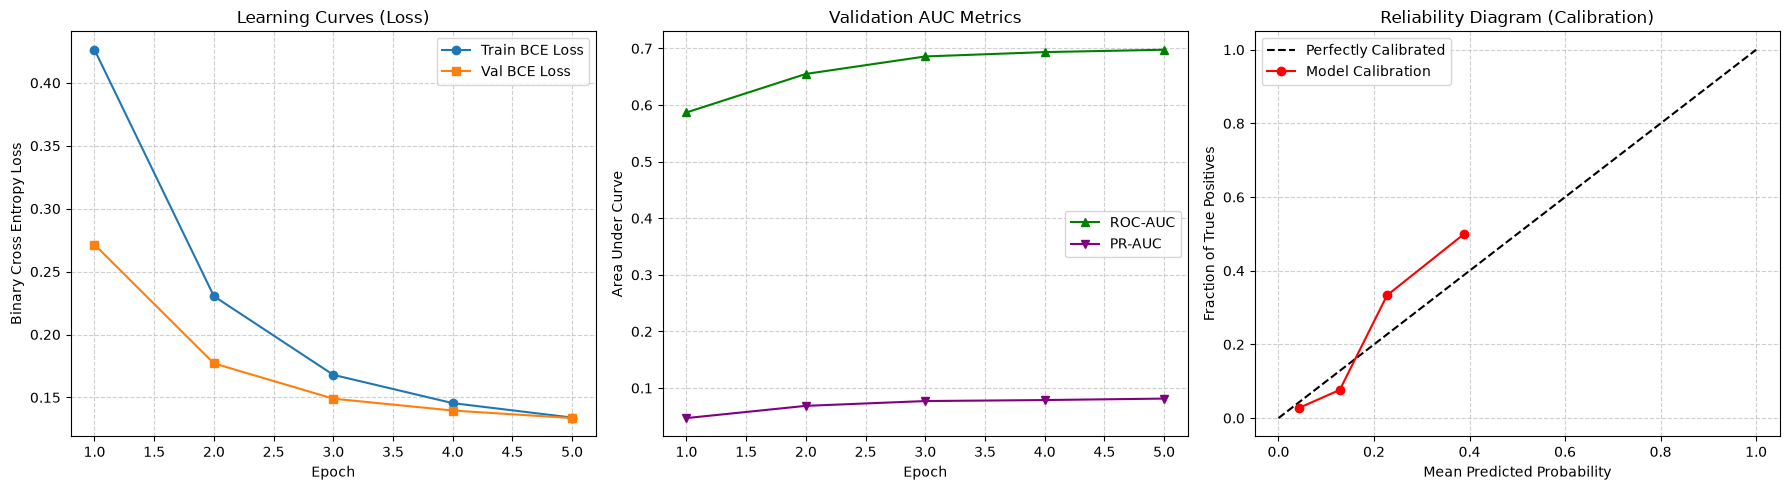

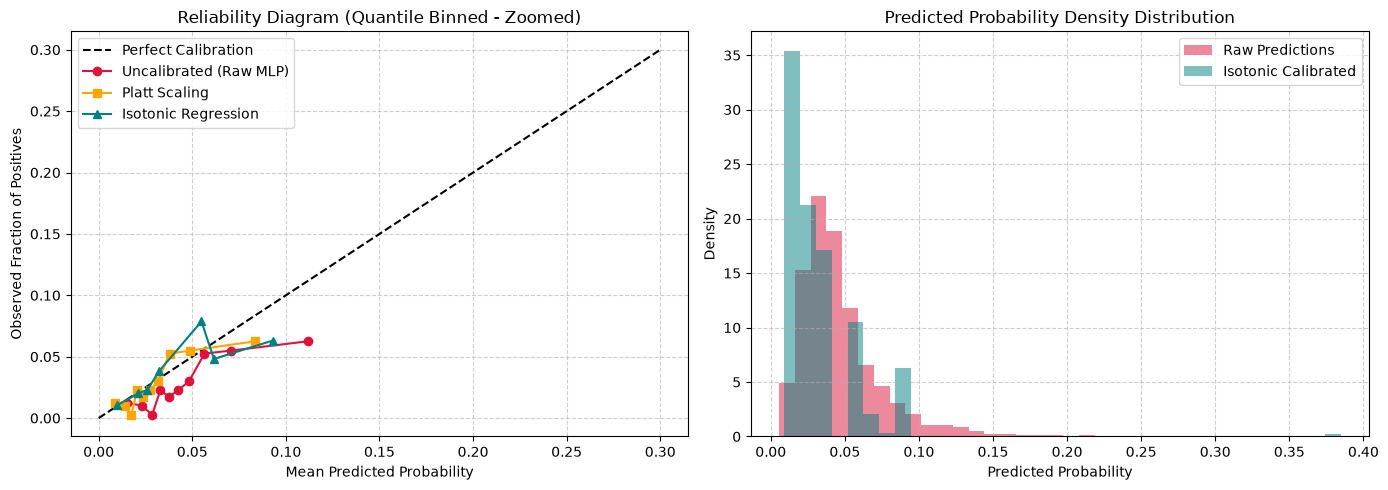

In [36]:
def plot_task2_metrics(history, all_preds, all_targets):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    epochs_range = range(1, len(history['train_loss']) + 1)
    axes[0].plot(epochs_range, history['train_loss'], label='Train BCE Loss', marker='o')
    axes[0].plot(epochs_range, history['val_loss'], label='Val BCE Loss', marker='s')
    axes[0].set_title('Learning Curves (Loss)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Binary Cross Entropy Loss')
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.6)

    axes[1].plot(epochs_range, history['val_roc_auc'], label='ROC-AUC', color='green', marker='^')
    axes[1].plot(epochs_range, history['val_pr_auc'], label='PR-AUC', color='purple', marker='v')
    axes[1].set_title('Validation AUC Metrics')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Area Under Curve')
    axes[1].legend()
    axes[1].grid(True, linestyle="--", alpha=0.6)

    prob_true, prob_pred = calibration_curve(all_targets, all_preds, n_bins=10, strategy='uniform')
    axes[2].plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfectly Calibrated')
    axes[2].plot(prob_pred, prob_true, marker='o', color='red', label='Model Calibration')
    axes[2].set_title('Reliability Diagram (Calibration)')
    axes[2].set_xlabel('Mean Predicted Probability')
    axes[2].set_ylabel('Fraction of True Positives')
    axes[2].legend()
    axes[2].grid(True, linestyle="--", alpha=0.6)
    
    plt.tight_layout()
    plt.savefig("task2_metrics.png", dpi=300)
    plt.show()

plot_task2_metrics(history_vanilla, preds_vanilla, targets_vanilla)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

prob_true_raw, prob_pred_raw = calibration_curve(test_targets, test_preds, n_bins=10, strategy='quantile')
prob_true_platt, prob_pred_platt = calibration_curve(test_targets, preds_platt, n_bins=10, strategy='quantile')
prob_true_iso, prob_pred_iso = calibration_curve(test_targets, preds_iso, n_bins=10, strategy='quantile')

axes[0].plot([0, max(prob_pred_raw.max(), 0.3)], [0, max(prob_pred_raw.max(), 0.3)], 'k--', label='Perfect Calibration')
axes[0].plot(prob_pred_raw, prob_true_raw, marker='o', color='crimson', label='Uncalibrated (Raw MLP)')
axes[0].plot(prob_pred_platt, prob_true_platt, marker='s', color='orange', label='Platt Scaling')
axes[0].plot(prob_pred_iso, prob_true_iso, marker='^', color='teal', label='Isotonic Regression')
axes[0].set_title('Reliability Diagram (Quantile Binned - Zoomed)')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Observed Fraction of Positives')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].hist(test_preds, bins=35, alpha=0.5, label='Raw Predictions', color='crimson', density=True)
axes[1].hist(preds_iso, bins=35, alpha=0.5, label='Isotonic Calibrated', color='teal', density=True)
axes[1].set_title('Predicted Probability Density Distribution')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("recalibrated_task2_metrics.png", dpi=300)
plt.show()

# Observations-NOTE:


In the first two graphs, as you can see the train and val loss curves are pretty satisfcatory and properly cnverge to around 0.14.

The ROC curve climbing steadily to around 0.68 indicates the model has learnt to recognise "clicks on teh ad" more than it does for "ignores on the ad".

The PR curve remaining below 0.10 indicates the class imbalance in CTR prediction. So the model is good at relative ranking but is poor when it comes to abs prediction because clicks are already very rare.

Due to class imbalance in the dataset itself(which is real for an ad dataset because ad clicks are very rare in real life, barely 1-3%),the threshold of F1 score being default at 0.5 causes it to flatter at 0.0 itself in the regular Vannila ctr model before calibration. After recalibration, the optimal F1 threshold(isotonic) was found out to be at 0.479 and the F1 score rose to 0.1351.

For recalibration, platt scaling and isotonic regression is used, and they have evidently(seen from graph) improve dthe calibrated curve to be close to the perfect calibration making it more reliable.

# DCN


In [37]:
class CrossLayer(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(input_dim))
        self.bias = nn.Parameter(torch.empty(input_dim))
        nn.init.normal_(self.weight, std=0.01)
        nn.init.zeros_(self.bias)

    def forward(self, x0, xl):
        xl_w = (xl * self.weight).sum(dim=1, keepdim=True)
        return x0 * xl_w + self.bias + xl

class DeepAndCrossNetwork(nn.Module):
    def __init__(self, num_numeric, cat_dims, embed_dim=16, hidden_dims=[128, 64], num_cross_layers=2):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_embeddings=dim, embedding_dim=embed_dim)
            for dim in cat_dims
        ])
        
        total_input_dim = num_numeric + (len(cat_dims) * embed_dim)

        self.cross_layers = nn.ModuleList([
            CrossLayer(total_input_dim) for _ in range(num_cross_layers)
        ])

        deep_layers = []
        in_dim = total_input_dim
        for out_dim in hidden_dims:
            deep_layers.append(nn.Linear(in_dim, out_dim))
            deep_layers.append(nn.BatchNorm1d(out_dim))
            deep_layers.append(nn.ReLU())
            deep_layers.append(nn.Dropout(0.2))
            in_dim = out_dim
        self.deep_network = nn.Sequential(*deep_layers)
        
        # Final combination layer: concatenates Cross output + Deep output
        self.final_linear = nn.Linear(total_input_dim + in_dim, 1)

    def forward(self, numeric_x, cat_x):
        cat_embeds = [emb(cat_x[:, i]) for i, emb in enumerate(self.embeddings)]
        cat_concat = torch.cat(cat_embeds, dim=1)

        x0 = torch.cat([numeric_x, cat_concat], dim=1)

        xl = x0
        for cross_layer in self.cross_layers:
            xl = cross_layer(x0, xl)

        deep_out = self.deep_network(x0)

        combined = torch.cat([xl, deep_out], dim=1)
        logits = self.final_linear(combined).squeeze(1)
        return logits

In [38]:
def train_and_evaluate(model, train_loader, val_loader, epochs=5, lr=0.001, weight_decay=1e-4):
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    model = model.to(device)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    history = {'train_loss': [], 'val_loss': [], 'val_roc_auc': [], 'val_pr_auc': []}
    
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        for num_x, cat_x, labels in train_loader:
            num_x, cat_x, labels = num_x.to(device), cat_x.to(device), labels.to(device).float()
            
            optimizer.zero_grad()
            logits = model(num_x, cat_x)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            
            total_train_loss += loss.item()
            
        avg_train_loss = total_train_loss / len(train_loader)
        
        # Validation Phase
        model.eval()
        total_val_loss = 0
        all_preds = []
        all_targets = []
        
        with torch.no_grad():
            for num_x, cat_x, labels in val_loader:
                num_x, cat_x, labels = num_x.to(device), cat_x.to(device), labels.to(device).float()
                logits = model(num_x, cat_x)
                loss = criterion(logits, labels)
                total_val_loss += loss.item()
                
                probs = torch.sigmoid(logits)
                all_preds.extend(probs.cpu().numpy())
                all_targets.extend(labels.cpu().numpy())
                
        avg_val_loss = total_val_loss / len(val_loader)
        val_roc_auc = roc_auc_score(all_targets, all_preds)
        val_pr_auc = average_precision_score(all_targets, all_preds)
        
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_roc_auc'].append(val_roc_auc)
        history['val_pr_auc'].append(val_pr_auc)
        
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | ROC-AUC: {val_roc_auc:.4f}")
        
    return history, all_preds, all_targets

In [39]:
def plot_task2_metrics(history, all_preds, all_targets):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    epochs_range = range(1, len(history['train_loss']) + 1)
    axes[0].plot(epochs_range, history['train_loss'], label='Train BCE Loss', marker='o')
    axes[0].plot(epochs_range, history['val_loss'], label='Val BCE Loss', marker='s')
    axes[0].set_title('Learning Curves (Loss)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Binary Cross Entropy Loss')
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.6)
    
    axes[1].plot(epochs_range, history['val_roc_auc'], label='ROC-AUC', color='green', marker='^')
    axes[1].plot(epochs_range, history['val_pr_auc'], label='PR-AUC', color='purple', marker='v')
    axes[1].set_title('Validation AUC Metrics')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Area Under Curve')
    axes[1].legend()
    axes[1].grid(True, linestyle="--", alpha=0.6)

    prob_true, prob_pred = calibration_curve(all_targets, all_preds, n_bins=10, strategy='uniform')
    axes[2].plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfectly Calibrated')
    axes[2].plot(prob_pred, prob_true, marker='o', color='red', label='Model Calibration')
    axes[2].set_title('Reliability Diagram (Calibration)')
    axes[2].set_xlabel('Mean Predicted Probability')
    axes[2].set_ylabel('Fraction of True Positives')
    axes[2].legend()
    axes[2].grid(True, linestyle="--", alpha=0.6)
    
    plt.tight_layout()
    plt.savefig("task2_metrics.png", dpi=300)
    plt.show()

Training Deep & Cross Network
Epoch 1/10 | Train Loss: 0.2871 | Val Loss: 0.1529 | ROC-AUC: 0.5947
Epoch 2/10 | Train Loss: 0.1468 | Val Loss: 0.1345 | ROC-AUC: 0.6717
Epoch 3/10 | Train Loss: 0.1353 | Val Loss: 0.1305 | ROC-AUC: 0.6910
Epoch 4/10 | Train Loss: 0.1299 | Val Loss: 0.1292 | ROC-AUC: 0.7037
Epoch 5/10 | Train Loss: 0.1264 | Val Loss: 0.1307 | ROC-AUC: 0.7020
Epoch 6/10 | Train Loss: 0.1234 | Val Loss: 0.1301 | ROC-AUC: 0.6989
Epoch 7/10 | Train Loss: 0.1207 | Val Loss: 0.1312 | ROC-AUC: 0.6879
Epoch 8/10 | Train Loss: 0.1172 | Val Loss: 0.1308 | ROC-AUC: 0.6983
Epoch 9/10 | Train Loss: 0.1136 | Val Loss: 0.1317 | ROC-AUC: 0.6898
Epoch 10/10 | Train Loss: 0.1095 | Val Loss: 0.1317 | ROC-AUC: 0.6894


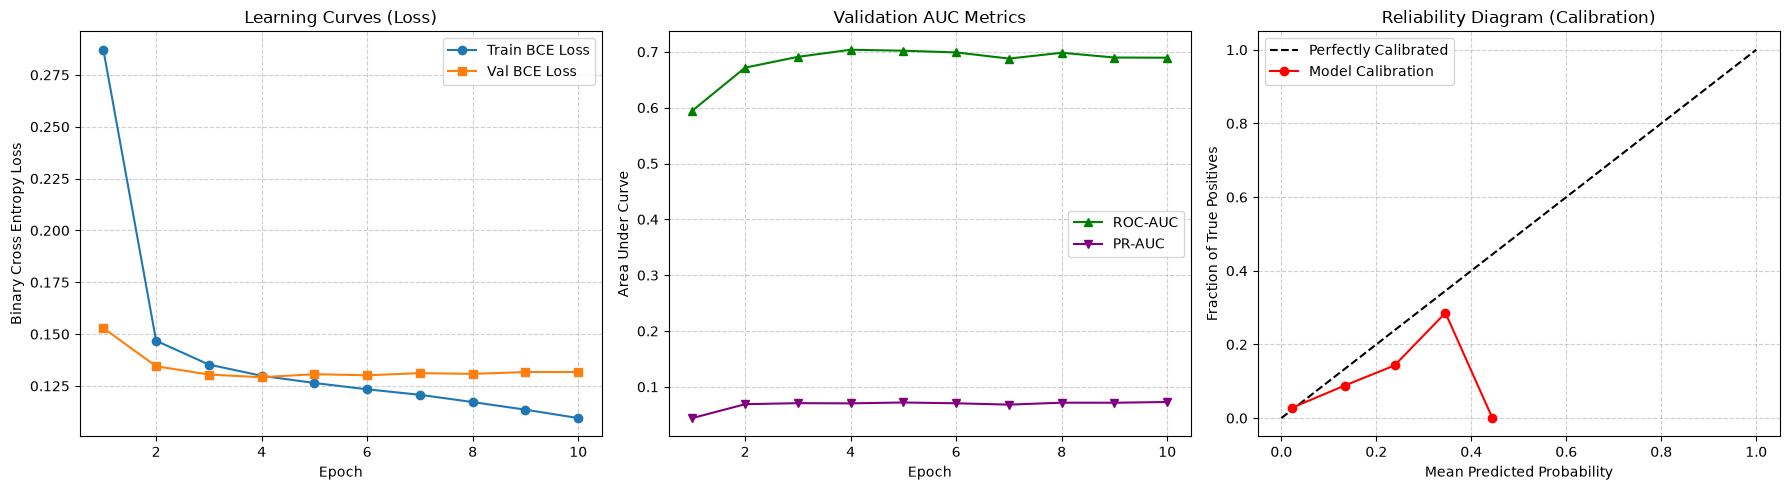

In [40]:
dcn_model = DeepAndCrossNetwork(
    num_numeric=num_numeric, 
    cat_dims=cat_dims, 
    embed_dim=16, 
    hidden_dims=[128, 64],
    num_cross_layers=2
)

print("Training Deep & Cross Network")
history_dcn, preds_dcn, targets_dcn = train_and_evaluate(
    model=dcn_model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    epochs=10, 
    lr=0.0005, 
    weight_decay=1e-4
)

plot_task2_metrics(history_dcn, preds_dcn, targets_dcn)

**OBSERVATIONS**:

BEFORE L2 Regularization:

In the DCN model, the ROC-AUC score has improved to reached 0.6973 by epoch2 while the vannila nn's baseline was at 0.681 . From the loss curves we can see that the validation loss reached the absolute lowest by epoch 3 itself which is faster than vanilla. But the curve also creeps up after that indicating overfitting this is because this is memory dense model, causing it to memrise after epoch 3. Early stoppping(by epoch 3) can prevent overfitting.

Due to higher ROC-AUC score, it is true that DCN is better at ranking than vanilla, but from the reliability diagram we can see that it also needs calibration. Using isotonic regression will make it better but due to time constraints, I have not implemented early stopping or lr scheduling and calibration.

AFTER L2 regularizatio using Adam:

->The ROC-AUC score has crossed the prev ceiling of 0.6973 and has crept above 7.0 thus making the overall model even better at ranking.

-> Still overfitting doesnt seem to have resolved.